### Блок 1. Исследование динамики агрегированного импорта медицинского оборудования в РФ

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

#### Подготовка и вспомогательный функции 

In [2]:
data = pd.read_excel('data/final_data.xlsx')
data["rep_date"] = pd.to_datetime(data["rep_date"])
data = data.sort_values(["rep_date", "country", "hs"]).reset_index(drop=True)

monthly = (
    data.groupby("rep_date", as_index=False)["value"]
    .sum()
    .rename(columns={"value": "total_import_value"})
    .sort_values("rep_date")
)

monthly

,rep_date,total_import_value
0,2019-01-01,2.631455e+08
1,2019-02-01,2.988145e+08
2,2019-03-01,3.797893e+08
3,2019-04-01,3.531492e+08
4,2019-05-01,3.480698e+08
...,...,...
73,2025-02-01,3.264640e+08
74,2025-03-01,4.521075e+08
75,2025-04-01,4.324886e+08
76,2025-05-01,3.917702e+08


In [3]:
shock_date = pd.Timestamp("2022-02-01")

# Создаем папку для сохранения рисунков
save_dir = "figures/eda_block_1"
os.makedirs(save_dir, exist_ok=True)

In [4]:

import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory

def human_format(x, pos):
    """
    Красивый формат чисел на оси Y:
    1 200 000 000 -> 1.2B
    35 000 000    -> 35M
    8 000         -> 8K
    """
    abs_x = abs(x)
    if abs_x >= 1e9:
        return f"{x/1e9:.1f}B"
    elif abs_x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif abs_x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"


def percent_format(x, pos):
    """Формат процентов для оси Y."""
    return f"{x:.0f}%"


def apply_thesis_style(ax, title, ylabel=None, xlabel=None, highlight_post_period=True):
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12, labelpad=15)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12, labelpad=15)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.5)
    ax.spines["bottom"].set_alpha(0.5)
    ax.tick_params(axis="both", labelsize=11)

    if highlight_post_period:
        # правая граница именно текущей оси
        x_left = mdates.date2num(shock_date)
        x_right = ax.get_xlim()[1]

        # красим до конца графика
        ax.axvspan(x_left, x_right, alpha=0.08, color="#B22222")
        ax.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

        # X в координатах данных, Y в долях оси
        trans = blended_transform_factory(ax.transData, ax.transAxes)

        # подпись чуть левее правого края красной зоны
        x_text = x_right - 0.02 * (x_right - x_left)

        ax.text(
            x_text, 0.04,
            "Постсанкционный период",
            transform=trans,
            color="#8B0000",
            fontsize=10,
            ha="right",
            va="bottom",
            linespacing=1.0
        )

def save_figure(fig, filename):
    """
    Сохраняем график сразу в PNG и PDF.
    PNG удобно вставлять в текст, PDF хорош для печати.
    """
    png_path = os.path.join(save_dir, f"{filename}.png")
    fig.savefig(png_path, dpi=400, bbox_inches="tight")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

#### График 1. Общий импорт по месяцам

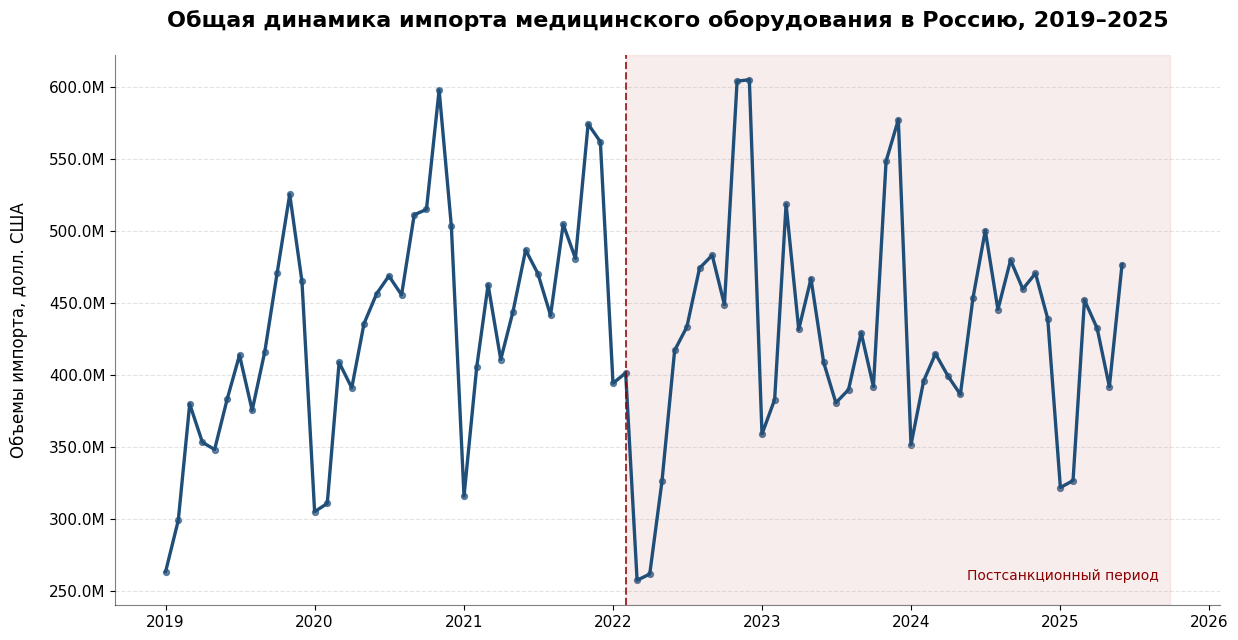

In [5]:
fig, ax = plt.subplots(figsize=(12.5, 6.5))

ax.plot(
    monthly["rep_date"],
    monthly["total_import_value"],
    linewidth=2.4,
    color="#1F4E79"
)

# Подчеркнем последние точки небольшими маркерами
ax.scatter(
    monthly["rep_date"],
    monthly["total_import_value"],
    s=18,
    color="#1F4E79",
    alpha=0.65
)

ax.yaxis.set_major_formatter(FuncFormatter(human_format))

apply_thesis_style(
    ax,
    title="Общая динамика импорта медицинского оборудования в Россию, 2019–2025",
    ylabel="Объемы импорта, долл. США"
)

save_figure(fig, "01_total_import_value_monthly")

На графике общей динамики видно, что в 2019–2021 гг. стоимостной импорт медицинского оборудования в Россию в целом рос, хотя этот рост сопровождался заметными месячными колебаниями. К концу докризисного периода месячные значения неоднократно выходили на уровни свыше 500 млн долл. США, что указывает на расширение импортных поставок до санкционного шока. После начала 2022 г. наблюдается резкое краткосрочное снижение импорта, отражающее первичную дезорганизацию поставок на фоне санкционного давления, логистических ограничений и перестройки внешнеторговых каналов. Однако в дальнейшем полного обрушения импорта не произошло: уже во второй половине 2022 г. и в 2023–2025 гг. объемы частично восстановились. При этом постсанкционный период выглядит более нестабильным: сохраняются значительные колебания месячных значений, а траектория становится менее ровной, чем в части докризисного периода. Это позволяет предположить, что после 2022 г. система импорта адаптировалась к новым условиям, но стала менее устойчивой.

#### График 3. Общий импорт со сглаживанием: 3 и 12 месяцев

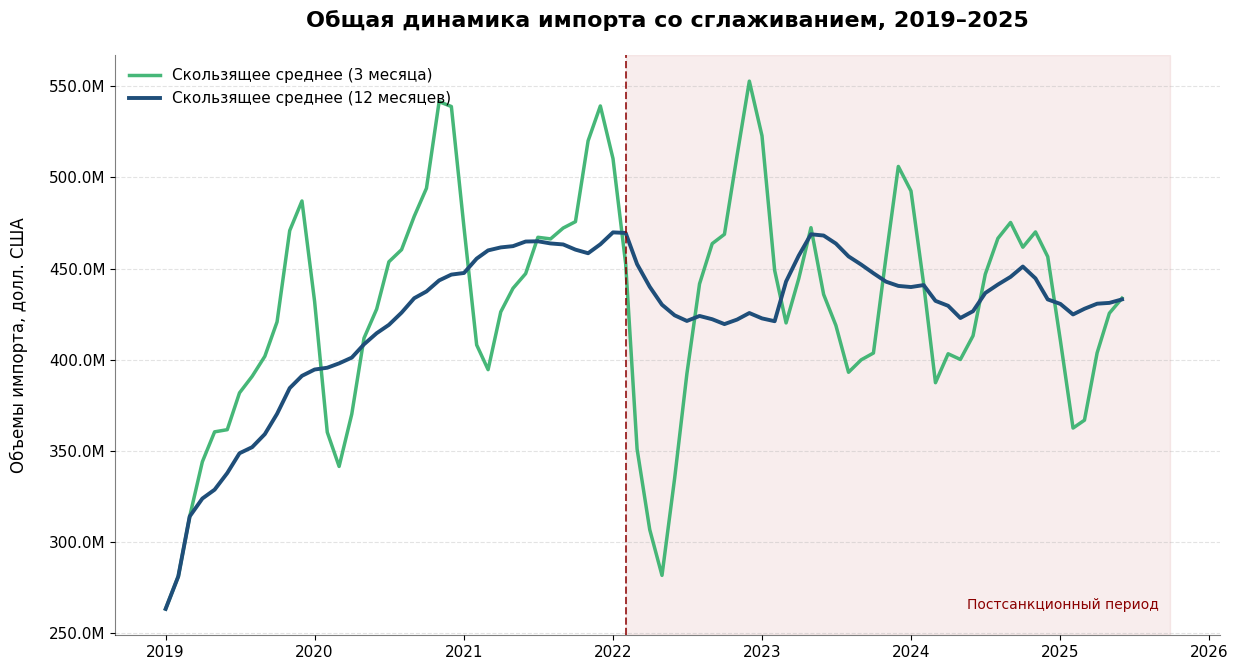

In [6]:
monthly["ma_3"] = monthly["total_import_value"].rolling(window=3, min_periods=1).mean()
monthly["ma_12"] = monthly["total_import_value"].rolling(window=12, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12.5, 6.8))


# 3-месячное сглаживание
ax.plot(
    monthly["rep_date"],
    monthly["ma_3"],
    linewidth=2.5,
    color="#3CB371",   # приглушенный стально-голубой
    alpha=0.95,
    label="Скользящее среднее (3 месяца)"
)

# 12-месячное сглаживание
ax.plot(
    monthly["rep_date"],
    monthly["ma_12"],
    linewidth=2.8,
    color="#1F4E79",   # глубокий темно-синий
    label="Скользящее среднее (12 месяцев)"
)

ax.yaxis.set_major_formatter(FuncFormatter(human_format))

apply_thesis_style(
    ax,
    title="Общая динамика импорта со сглаживанием, 2019–2025",
    ylabel="Объемы импорта, долл. США"
)

ax.legend(frameon=False, fontsize=11, loc="upper left")

save_figure(fig, "02_total_import_value_with_rolling_means")

Сглаженные ряды позволяют лучше отделить краткосрочные всплески от основного тренда. Трехмесячное скользящее среднее показывает, что после 2022 г. амплитуда краткосрочных колебаний остается высокой: периоды восстановления быстро сменяются новыми просадками. В то же время двенадцатимесячное скользящее среднее отражает более важный долгосрочный результат: если до 2022 г. наблюдался выраженный восходящий тренд, то после санкционного шока долгосрочная траектория сначала снижается, а затем стабилизируется на более низком уровне, чем в конце докризисного периода. Иными словами, шок 2022 г. не только вызвал краткосрочный провал, но и прервал прежний тренд роста. Последующее восстановление оказалось неполным: импорт не исчез, но перешел в новый режим, характеризующийся более умеренными средними объемами и большей турбулентностью.

#### График 3. Годовые темпы роста (YoY)

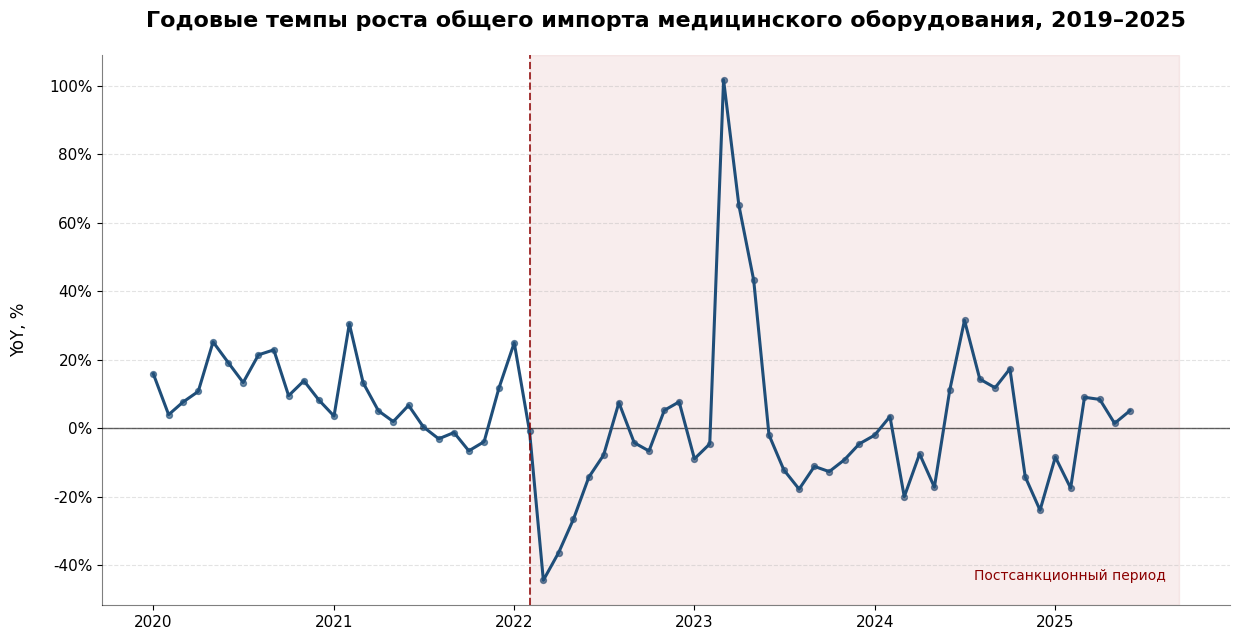

In [7]:
# Годовой темп роста относительно того же месяца прошлого года
monthly["yoy_growth_pct"] = monthly["total_import_value"].pct_change(12) * 100

fig, ax = plt.subplots(figsize=(12.5, 6.5))

ax.axhline(0, color="black", linewidth=1.0, alpha=0.6)

ax.plot(
    monthly["rep_date"],
    monthly["yoy_growth_pct"],
    linewidth=2.2,
    color="#1F4E79"
)

# Точки на графике
ax.scatter(
    monthly["rep_date"],
    monthly["yoy_growth_pct"],
    s=18,
    color="#1F4E79",
    alpha=0.65
)

ax.yaxis.set_major_formatter(FuncFormatter(percent_format))

apply_thesis_style(
    ax,
    title="Годовые темпы роста общего импорта медицинского оборудования, 2019–2025",
    ylabel="YoY, %"
)

save_figure(fig, "03_total_import_value_yoy_growth")

График годовых темпов роста особенно наглядно показывает смену режима в 2022 г. В первой половине рассматриваемого периода годовые темпы роста в основном оставались положительными, что соответствует общему увеличению стоимостного импорта в 2019–2021 гг. После начала санкционного периода фиксируется резкое падение: в отдельные месяцы 2022 г. годовое снижение достигает примерно 40–45%, что отражает сильный негативный эффект первичного шока. Далее, в 2023 г., появляются очень высокие положительные темпы роста, включая пик свыше 100%, однако их следует интерпретировать осторожно: в значительной степени они связаны с эффектом низкой базы после провала 2022 г., а не с устойчивым расширением импорта. В 2023–2025 гг. годовые темпы роста колеблются вокруг нуля и периодически переходят из положительной области в отрицательную, что указывает на отсутствие устойчивой восстановительной траектории. Таким образом, постсанкционный период характеризуется не стабильным ростом, а чередованием фаз восстановления и нового ослабления.

#### График 4. Сезонный профиль: до и после 2022 года

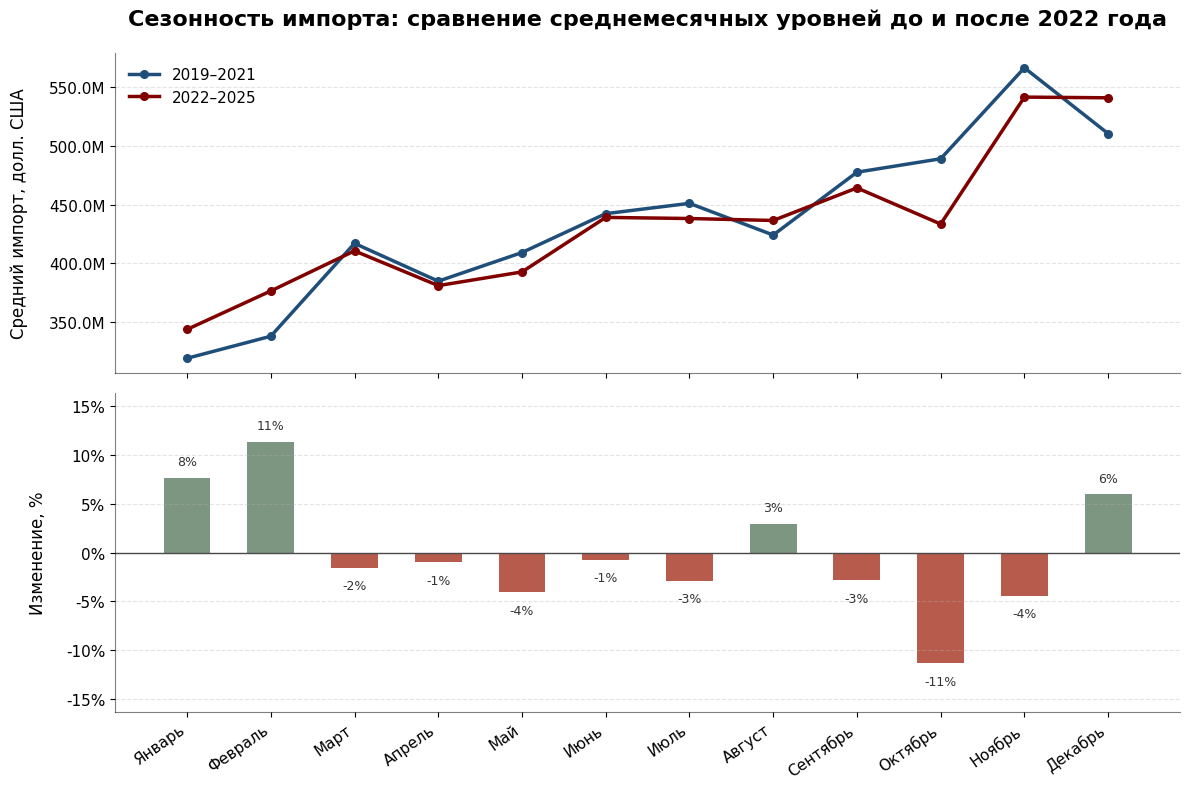

In [11]:
seasonal = monthly.copy()

# Номер месяца
seasonal["month_num"] = seasonal["rep_date"].dt.month

# Полные названия месяцев
month_labels_full = {
    1: "Январь", 2: "Февраль", 3: "Март", 4: "Апрель",
    5: "Май", 6: "Июнь", 7: "Июль", 8: "Август",
    9: "Сентябрь", 10: "Октябрь", 11: "Ноябрь", 12: "Декабрь"
}

# Делим на периоды
seasonal["period_group"] = np.where(
    seasonal["rep_date"] < shock_date,
    "2019–2021",
    "2022–2025"
)

# Средний импорт по календарным месяцам отдельно для двух периодов
seasonal_avg = (
    seasonal.groupby(["period_group", "month_num"], as_index=False)["total_import_value"]
    .mean()
)

# Wide-формат
seasonal_wide = seasonal_avg.pivot(
    index="month_num",
    columns="period_group",
    values="total_import_value"
).reset_index()

seasonal_wide = seasonal_wide.sort_values("month_num")

# Процентное изменение
seasonal_wide["pct_change"] = (
    (seasonal_wide["2022–2025"] - seasonal_wide["2019–2021"]) /
    seasonal_wide["2019–2021"] * 100
)

fig, (ax0, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    gridspec_kw={"height_ratios": [1.6, 1.6]},
    sharex=True
)

x = np.arange(len(seasonal_wide))
bar_width = 0.36

# -----------------------------
# 1. Верхняя панель: две ломаные
# -----------------------------
ax0.plot(
    x,
    seasonal_wide["2019–2021"],
    linewidth=2.5,
    marker="o",
    markersize=5.5,
    color="#1F4E79",
    label="2019–2021"
)

ax0.plot(
    x,
    seasonal_wide["2022–2025"],
    linewidth=2.5,
    marker="o",
    markersize=5.5,
    color="#800000",
    label="2022–2025"
)

ax0.yaxis.set_major_formatter(FuncFormatter(human_format))

apply_thesis_style(
    ax0,
    title="Сезонность импорта: сравнение среднемесячных уровней до и после 2022 года",
    ylabel="Средний импорт, долл. США",
    xlabel=None,
    highlight_post_period=False
)

ax0.legend(frameon=False, fontsize=11, loc="upper left")

# # -----------------------------
# # 2. Средняя панель: столбики
# # -----------------------------
# ax1.bar(
#     x - bar_width / 2,
#     seasonal_wide["2019–2021"],
#     width=bar_width,
#     color="#1F4E79",
#     alpha=0.92,
#     label="2019–2021"
# )

# ax1.bar(
#     x + bar_width / 2,
#     seasonal_wide["2022–2025"],
#     width=bar_width,
#     color="#800000",
#     alpha=0.88,
#     label="2022–2025"
# )

# ax1.yaxis.set_major_formatter(FuncFormatter(human_format))

# apply_thesis_style(
#     ax1,
#     title="",
#     ylabel="Средний месячный импорт, долл. США",
#     xlabel=None,
#     highlight_post_period=False
# )

# # убираем пустой заголовок, который создала функция
# ax1.set_title("")

# -----------------------------
# 3. Нижняя панель: % изменение
# -----------------------------
bars = ax2.bar(
    x,
    seasonal_wide["pct_change"],
    width=0.56,
    color=np.where(seasonal_wide["pct_change"] >= 0, "#6E8B74", "#B04A3A"),
    alpha=0.9
)

ax2.axhline(0, color="#4A4A4A", linewidth=1)

ymin = seasonal_wide["pct_change"].min()
ymax = seasonal_wide["pct_change"].max()
ax2.set_ylim(ymin - 5, ymax + 5)

ax2.set_ylabel("Изменение, %", fontsize=12, labelpad=14)
# ax2.set_xlabel("Месяц", fontsize=12, labelpad=14)
ax2.yaxis.set_major_formatter(FuncFormatter(percent_format))

ax2.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_alpha(0.5)
ax2.spines["bottom"].set_alpha(0.5)
ax2.tick_params(axis="both", labelsize=11)

ax2.set_xticks(x)
ax2.set_xticklabels(
    [month_labels_full[i] for i in seasonal_wide["month_num"]],
    rotation=35,
    ha="right"
)

for rect, val in zip(bars, seasonal_wide["pct_change"]):
    ax2.text(
        rect.get_x() + rect.get_width() / 2,
        val + (1.0 if val >= 0 else -1.2),
        f"{val:.0f}%",
        ha="center",
        va="bottom" if val >= 0 else "top",
        fontsize=9,
        color="#333333"
    )

save_figure(fig, "04_seasonality_three_panel_pre_post")

Сравнение среднемесячных уровней по календарным месяцам показывает, что сезонность импорта после 2022 г. не исчезла, но ее форма изменилась. В обоих периодах более низкие значения характерны для начала года, а более высокие — для осени и конца года, особенно для ноября и декабря. Это говорит о сохранении общей сезонной логики закупок и поставок. Вместе с тем в постсанкционный период сезонная траектория стала более сглаженной и частично перераспределенной внутри года. В частности, в январе и феврале средние уровни оказываются выше, чем в 2019–2021 гг., тогда как в ряде весенних и осенних месяцев, напротив, наблюдается некоторое снижение. Следовательно, после 2022 г. произошел не слом сезонности как таковой, а ее перестройка: годовой ритм поставок сохранился, но отдельные месяцы стали играть иную роль в распределении импортных потоков.


Более детальное сравнение среднемесячных уровней показывает, что изменения сезонного профиля были неоднородными. Наиболее заметный рост средних объемов в постсанкционный период наблюдается в январе и феврале, а также в декабре; умеренное увеличение фиксируется в августе. Напротив, в большинстве месяцев с марта по ноябрь средние объемы оказываются ниже докризисных значений, причем особенно сильное снижение приходится на октябрь. Это может указывать на смещение части импортных поставок на более ранние месяцы года и на конец года, тогда как в середине и в начале осени поставки стали менее интенсивными. В аналитическом смысле этот результат важен, потому что он говорит о перестройке внутригодовой логики импорта: санкционный шок повлиял не только на общий уровень поставок, но и на календарное распределение внешнеторговых потоков. Для дальнейшего моделирования это означает, что сезонные эффекты необходимо учитывать явно, а сама сезонность после 2022 г. может быть нестабильной и зависеть от нового внешнеторгового режима.